In [31]:
from sklearn.datasets import make_regression

import numpy as np
import matplotlib.pyplot as plt

In [32]:
# use inline backend to avoid the VS Code widget warning
%matplotlib inline
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

In [33]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

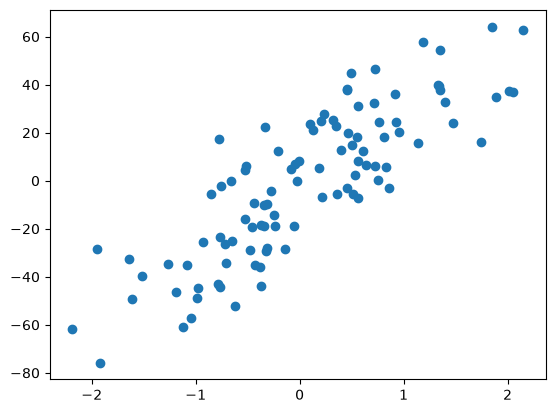

In [34]:
plt.scatter(X,y)

In [35]:
b = -520
m = 600
lr = 0.001
all_b = []
all_m = []
all_cost = []

epochs = 30

for _ in range(epochs):
    slope_b = 0.0
    slope_m = 0.0
    cost = 0.0

    for x_i, y_i in zip(X.ravel(), y.ravel()):
        error = y_i - (m * x_i + b)
        slope_b += -2 * error
        slope_m += -2 * error * x_i
        cost += error ** 2

    b = b - (lr * slope_b)
    m = m - (lr * slope_m)
    all_b.append(b)
    all_m.append(m)
    all_cost.append(cost / len(y))

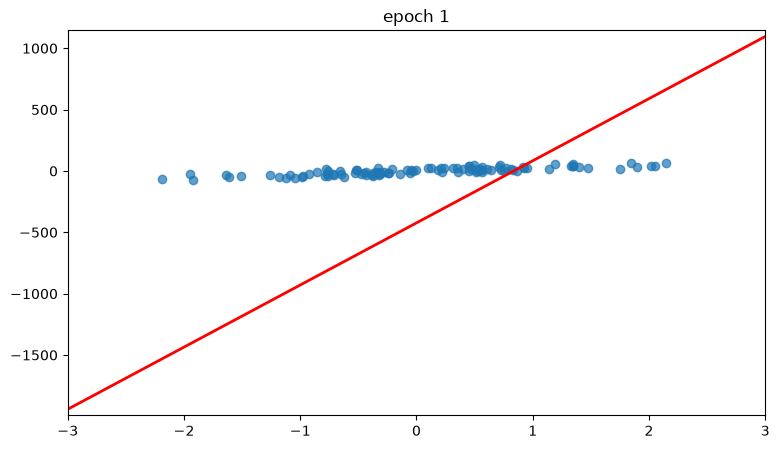

In [36]:
x_i = np.linspace(-3, 3, 200)
predicted_lines = np.array([x_i * m_i + b_i for m_i, b_i in zip(all_m, all_b)])

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X, y, color='tab:blue', alpha=0.7)
line, = ax.plot([], [], color='red', linewidth=2)

ax.set_xlim(-3, 3)
ax.set_ylim(predicted_lines.min() - 50, predicted_lines.max() + 50)

def update(i):
    line.set_data(x_i, predicted_lines[i])
    ax.set_title(f'epoch {i + 1}')
    return line,

anim = FuncAnimation(fig, update, frames=epochs, interval=500, repeat=False)

try:
    anim.save('animation4.gif', writer=animation.PillowWriter(fps=2))
except Exception as exc:

    print(f'GIF save skipped: {exc}')
    plt.show()


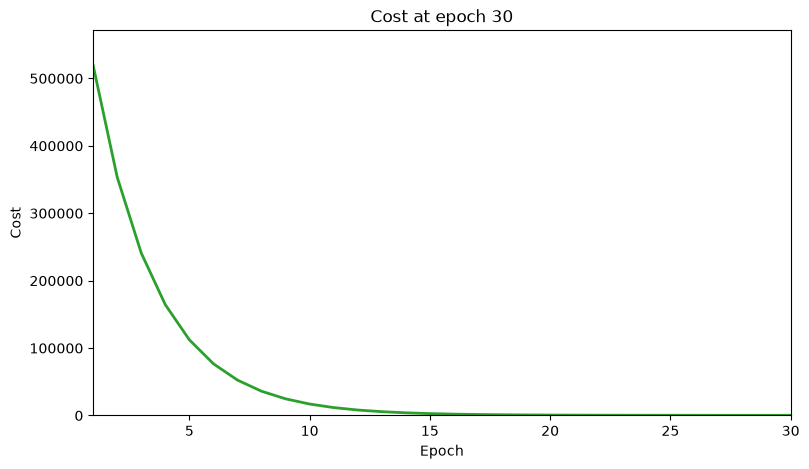

In [37]:
epochs_list = list(range(1, epochs + 1))

fig, axis = plt.subplots(figsize=(9, 5))
line, = axis.plot([], [], lw=2, color='tab:green')
xdata, ydata = [], []

def animate(i):
    xdata.append(epochs_list[i])
    ydata.append(all_cost[i])
    line.set_data(xdata, ydata)
    axis.set_xlim(1, epochs)
    axis.set_ylim(0, max(all_cost) * 1.1 if max(all_cost) > 0 else 1)
    axis.set_xlabel('Epoch')
    axis.set_ylabel('Cost')
    axis.set_title(f'Cost at epoch {i + 1}')
    return line,

anim = FuncAnimation(fig, animate, frames=epochs, interval=500, repeat=False)

try:
    anim.save('animation5.gif', writer=animation.PillowWriter(fps=2))
except Exception as exc:
    print(f'GIF save skipped: {exc}')

plt.show()

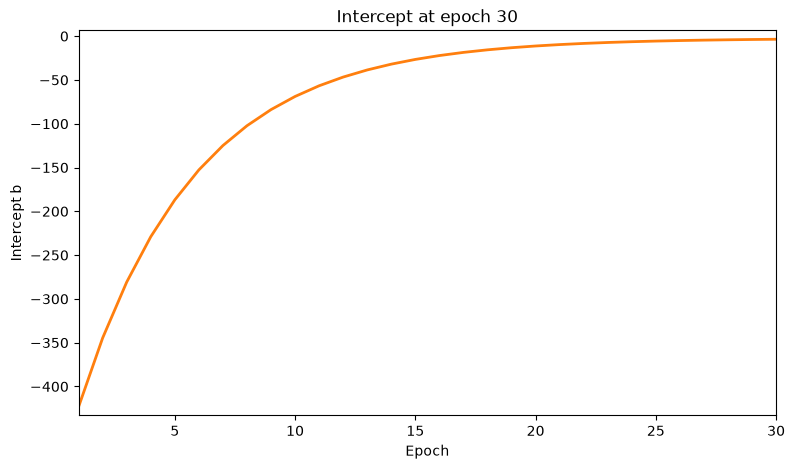

In [38]:
fig, axis = plt.subplots(figsize=(9, 5))
line, = axis.plot([], [], lw=2, color='tab:orange')
xdata, ydata = [], []

def animate(i):
    xdata.append(epochs_list[i])
    ydata.append(all_b[i])
    line.set_data(xdata, ydata)
    axis.set_xlim(1, epochs)
    axis.set_ylim(min(all_b) - 10, max(all_b) + 10)
    axis.set_xlabel('Epoch')
    axis.set_ylabel('Intercept b')
    axis.set_title(f'Intercept at epoch {i + 1}')
    return line,

anim = FuncAnimation(fig, animate, frames=epochs, interval=500, repeat=False)

try:
    anim.save('animation6.gif', writer=animation.PillowWriter(fps=2))
except Exception as exc:
    print(f'GIF save skipped: {exc}')

plt.show()

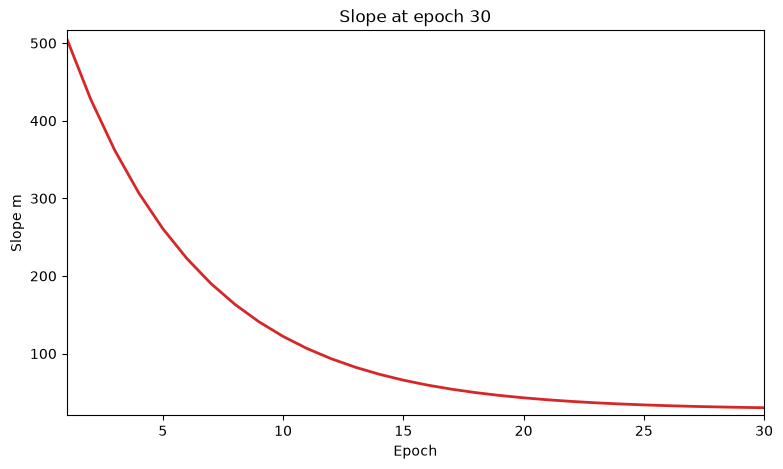

In [39]:
fig, axis = plt.subplots(figsize=(9, 5))
line, = axis.plot([], [], lw=2, color='tab:red')
xdata, ydata = [], []

def animate(i):
    xdata.append(epochs_list[i])
    ydata.append(all_m[i])
    line.set_data(xdata, ydata)
    axis.set_xlim(1, epochs)
    axis.set_ylim(min(all_m) - 10, max(all_m) + 10)
    axis.set_xlabel('Epoch')
    axis.set_ylabel('Slope m')
    axis.set_title(f'Slope at epoch {i + 1}')
    return line,

anim = FuncAnimation(fig, animate, frames=epochs, interval=500, repeat=False)

try:
    anim.save('animation7.gif', writer=animation.PillowWriter(fps=2))
except Exception as exc:
    print(f'GIF save skipped: {exc}')

plt.show()